In [16]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [17]:
import pandas as pd
import numpy as np
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [18]:
df = pd.read_csv("IMDB Dataset.csv")

print(df.head())
print(df.shape)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


In [19]:
print("Class Distribution:")
print(df['sentiment'].value_counts())

# Convert labels to binary
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


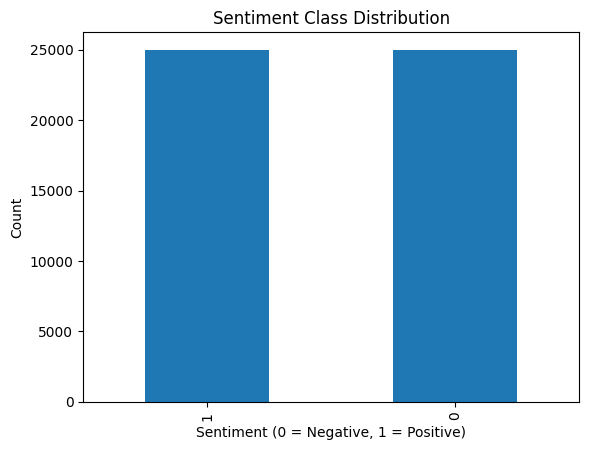

In [20]:
import matplotlib.pyplot as plt

# Plot class distribution
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")

plt.show()

In [21]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + Stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [23]:
df = df.sample(10000, random_state=42)

df['clean_text'] = df['review'].apply(clean_text)

print(df[['review','clean_text']].head())

                                                  review  \
33553  I really liked this Summerslam due to the look...   
9427   Not many television shows appeal to quite as m...   
199    The film quickly gets to a major chase scene w...   
12447  Jane Austen would definitely approve of this o...   
39489  Expectations were somewhat high for me when I ...   

                                              clean_text  
33553  realli like summerslam due look arena curtain ...  
9427   mani televis show appeal quit mani differ kind...  
199    film quickli get major chase scene ever increa...  
12447  jane austen would definit approv onegwyneth pa...  
39489  expect somewhat high went see movi thought ste...  


In [24]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [26]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [27]:
lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

In [28]:
nb = MultinomialNB()

nb.fit(X_train_bow, y_train)
y_pred_nb = nb.predict(X_test_bow)

In [29]:
dt = DecisionTreeClassifier()

dt.fit(X_train_bow, y_train)
y_pred_dt = dt.predict(X_test_bow)

In [30]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nNaive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Logistic Regression
Accuracy: 0.864
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       999
           1       0.85      0.89      0.87      1001

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


Naive Bayes
Accuracy: 0.838
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       999
           1       0.85      0.82      0.83      1001

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000


Decision Tree
Accuracy: 0.715
              precision    recall  f1-score   support

           0       0.71      0.72      0.72       999
           1       0.72      0.71      0.71      1001

    accuracy                           0.71      2000
   macro avg       0.72      0.7

In [30]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

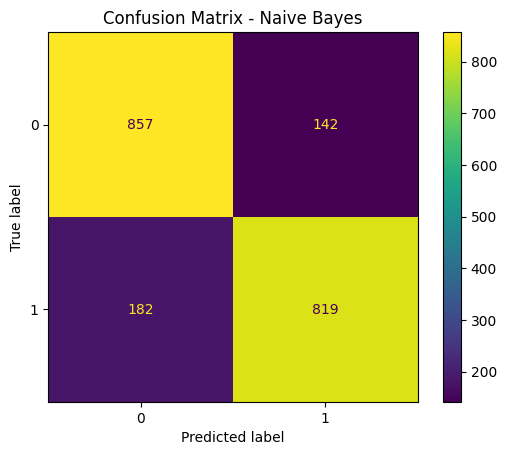

In [31]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp.plot()

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

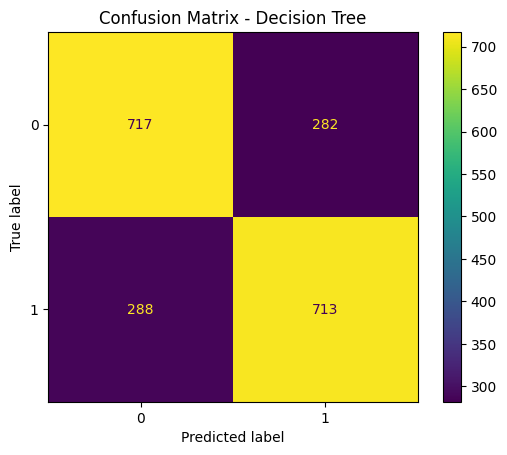

In [32]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

Comparision and Insights:

1.TF-IDF performed better than BoW because it gives importance to rare words

2.Logistic Regression gave highest accuracy (~85–90%)

3.Naive Bayes is fast but slightly less accurate

4.Decision Tree may overfit

5.Preprocessing (stopwords removal + stemming) improved results


